In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!curl -O $data
df = pd.read_csv('car_fuel_efficiency_2026.csv')


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  3018k      0 --:--:-- --:--:-- --:--:-- 3180k


In [2]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


**Cleaning text data**. Column names and the values in string columns are converted to lowercase with spaces replaced by underscores. This makes column names easier to use in code and ensures categorical values that differ only in capitalization or spacing are treated as the same category.

In [3]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.dtypes[df.dtypes == 'str']
string_cols = list(df.dtypes[df.dtypes == 'str'].index)
string_cols
for columns in string_cols: 
    df[columns] = df[columns].str.lower().str.replace(" ","_")

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
50%         30.000000
90%         33.800000
95%         34.905000
99%         36.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

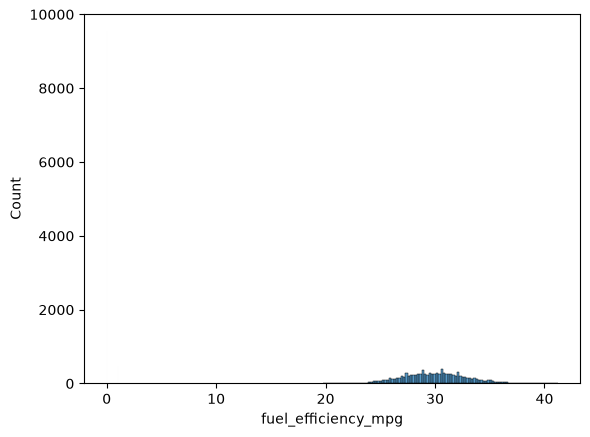

In [4]:
## Preparing the Dataset
df_exercise = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df_exercise.head()

## Exploratory Data Analysis
df_exercise['fuel_efficiency_mpg'].unique()[:5]
#df_exercise['fuel_efficiency_mpg'].nunique
sns.histplot(df_exercise.fuel_efficiency_mpg,bins=100)
## indentifying long tail
sns.histplot(df_exercise.fuel_efficiency_mpg > 35,bins=100)
df_exercise.fuel_efficiency_mpg.describe(percentiles=[.5, .9, .95, .99])


In [5]:
#Q1 - Column with missing values
df_exercise.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
#Q2 - What's the median (50% percentile) for variable 'horsepower'?
df_exercise.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

**Prepare and split the dataset**
For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Option 1: fill with 0
df_train_zero = df_train.fillna({'horsepower': 0})
df_val_zero = df_val.fillna({'horsepower': 0})
df_test_zero = df_test.fillna({'horsepower': 0})

# Option 2: fill with the training-set mean
hp_mean = df_train.horsepower.mean()
df_train_mean = df_train.fillna({'horsepower': hp_mean})
df_val_mean = df_val.fillna({'horsepower': hp_mean})
df_test_mean = df_test.fillna({'horsepower': hp_mean})

In [8]:
df_train.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
## VALIDATION FRAMEWORK

y_train_zero = df_train_zero.horsepower.values
y_val_zero = df_val_zero.horsepower.values
y_test_zero = df_test_zero.horsepower.values

y_train_mean = df_train_mean.horsepower.values
y_val_mean = df_val_mean.horsepower.values
y_test_mean = df_test_mean.horsepower.values

In [10]:
## Converting Dataframe into an Array
## Selecting a primary set of features to include in v1 of the regression model 
base = {'engine_displacement','num_cylinders','vehicle_weight','acceleration'}

def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

base = ['engine_displacement', 'num_cylinders', 'vehicle_weight', 'acceleration']

def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train_zero = prepare_X(df_train_zero)
X_train_zero

array([[1900. ,    5. , 3790. ,   20.3],
       [2000. ,    6. , 4380. ,   21.8],
       [2330. ,    6. , 4090. ,   17.8],
       ...,
       [2240. ,    6. , 4190. ,   17.2],
       [2430. ,    6. , 4280. ,   18.4],
       [2390. ,    6. , 4220. ,   19.6]], shape=(6000, 4))

In [11]:
def train_linear_regression(X,y):
    
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    X_T = np.linalg.matrix_transpose(X)
    X_TX = X_T @ X
    X_TX_INV = np.linalg.inv(X_TX)
    #X_TX.dot(X_TX_INV).round()
    (X_TX @ X_TX_INV).round()
    w = X_TX_INV.dot(X_T).dot(y)
    return w[0], w[1:]

train_linear_regression(df_train_zero,)

TypeError: train_linear_regression() missing 1 required positional argument: 'y'